# CP8305 Final Project
## Notebook 3 – Modeling (Diabetes 130-US Hospitals)

### Objectives
- Load the processed Diabetes 130-US dataset.
- Train and compare a comprehensive set of classifiers via leakage-safe k-fold stratified CV (fold count: `K_FOLDS` in Setup).
- Evaluate with AUC-ROC, AUPRC, F1, Cohen's Kappa, 95% CIs, and statistical significance tests.
- Conduct cost-sensitive threshold tuning aligned to HRRP readmission penalties.
- Produce SHAP, permutation importance, and PDP explainability artifacts.
- Export human-readable rules from tree-based models.

#### The methods we are using
* group-k-fold cross validation with confidence interval
-- we need group-k-fold to avoid data leakage since we have multiple encounters for the same patient.
* Kappa Statistic

#### Models

**Baselines:** ZeroR (majority class), OneR (single-split decision stump)

**Interpretable:** Gaussian Naive Bayes, Logistic Regression, SGDClassifier (log loss), Decision Tree (CART), kNN

**Ensemble:** Random Forest, Gradient Boosting, XGBoost, LightGBM

**Explainability:** SHAP, LIME, Permutation Importance, Partial Dependence Plots, Decision Rule Export


#### Metrics
* Accuracy & Balanced Accuracy
* Precision, Recall, F1, Weighted F1
* AUC-ROC, AUPRC (critical for imbalanced data)
* Cohen's Kappa (chance-corrected agreement)
* Precision@K and Recall@K (top-5%, top-10% operational capacity)
* Brier Score (calibration quality)
* 95% Confidence Intervals from fold distributions
* Paired t-test and Wilcoxon signed-rank significance tests

#### Evaluation Approach
All experiments use **stratified group k-fold cross-validation** (`K_FOLDS` folds, set in Section 1) with group-aware splitting (via `patient_nbr`) to prevent data leakage from repeated encounters. Preprocessing (scaling, SMOTE) is applied **strictly within each training fold**. Hyperparameter tuning uses **nested CV** (inner 5-fold) to produce unbiased performance estimates.

## 1. Setup

In [1]:
%pip install -r /scratch/indrisch/CP8305FP/requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Cross-validation: number of folds for all outer / standard stratified group CV in this notebook.
# Nested hyperparameter tuning keeps an inner 5-fold loop (run_tuned_cv_experiment(..., n_inner_splits=5)).
K_FOLDS = 10

import os
N_CPUS = int(os.environ.get('SLURM_CPUS_PER_TASK', os.cpu_count() or 4))
print(f'CPU budget: {N_CPUS}')

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))
TABLES_DIR = Path('..') / 'reports' / 'tables'
TABLES_DIR.mkdir(parents=True, exist_ok=True)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.modeling import (
    split_data,
    get_stratified_cv,
    CLASSIFICATION_MODELS,
    CLASSIFICATION_MODELS_FAST,
    CLASSIFICATION_MODELS_ADVANCED,
    CLASSIFICATION_MODELS_SGD,
    HYPERPARAM_GRIDS,
    SCALE_SENSITIVE_MODELS,
    build_fold_pipeline,
    compute_classification_metrics,
    compute_topk_metrics,
    compute_confidence_interval,
    run_cv_experiment,
    build_metrics_summary_table,
    run_significance_tests,
    compute_calibration_diagnostics,
    calibrate_model,
    compute_expected_cost,
    sweep_thresholds_cost,
    DEFAULT_COST_MATRIX,
    compute_shap_values,
    export_tree_rules,
    export_forest_top_rules,
    run_tuned_cv_experiment,
    compare_imbalance_strategies,
    predict_positive_probability,
    tune_decision_threshold,
    select_features_l1,
    train_classifier,
    evaluate_classifier,
    save_model,
    SHAP_AVAILABLE,
    LIME_AVAILABLE,
)
from src.visualization import (
    plot_confusion_matrix,
    plot_feature_importance,
    plot_permutation_importance,
    plot_roc_curves,
    plot_pr_curves,
    plot_calibration_curves,
    plot_model_comparison,
    plot_confidence_intervals,
    plot_cost_threshold_sweep,
    plot_shap_summary,
    plot_pdp,
    save_figure,
)

np.random.seed(42)
sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Load Processed Data

In [ ]:
DATA_FILE = Path('..') / 'data' / 'diabetes130' / 'processed' / 'processed_dataset.csv'
df = pd.read_csv(DATA_FILE)
print(f'Shape: {df.shape}')
df.head()

Shape: (69990, 2473)


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_binary,age_ordinal,...,admission_type_group_other,admission_type_group_urgent,discharge_group_inpatient,discharge_group_left_ama,discharge_group_other,discharge_group_transfer,admission_source_group_newborn,admission_source_group_other,admission_source_group_referral,admission_source_group_transfer
0,13,68,2,28,0,0,0,8,0,9,...,False,True,False,False,False,False,False,False,False,True
1,12,33,3,18,0,0,0,8,0,10,...,False,False,False,False,False,True,False,False,False,True
2,1,51,0,8,0,0,0,5,0,5,...,False,False,False,False,False,False,False,False,False,False
3,9,47,2,17,0,0,0,9,0,5,...,False,False,False,False,False,False,False,False,False,False
4,3,31,6,16,0,0,0,9,0,6,...,False,True,False,False,False,False,False,False,True,False


## 3. Feature / Target Split

In [5]:
# Target column used in preprocessing notebook.
TARGET = 'readmitted_binary'

# Keep patient_nbr only for optional group-aware CV, never as a model feature.
group_ids = df['patient_nbr'].copy() if 'patient_nbr' in df.columns else None

drop_columns = [TARGET]
for leakage_col in ['encounter_id', 'patient_nbr']:
    if leakage_col in df.columns:
        drop_columns.append(leakage_col)

X = df.drop(columns=drop_columns)
y = df[TARGET]

print(f'Features: {X.shape[1]}  |  Target: {y.name}  |  Classes/Values: {y.nunique()}')
if group_ids is not None:
    print('Group-aware CV is enabled via patient_nbr (excluded from X).')
else:
    print('Group-aware CV unavailable (patient_nbr not present in processed data).')

Features: 2472  |  Target: readmitted_binary  |  Classes/Values: 2
Group-aware CV unavailable (patient_nbr not present in processed data).


In [6]:
# Split once up-front with stratification so class imbalance is preserved.
X_train, X_test, y_train, y_test = split_data(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=True,
 )

# If group IDs are available, keep the train-split groups for CV-only use.
groups_train = group_ids.loc[X_train.index] if group_ids is not None else None

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Positive class ratio (train): {y_train.mean():.4f}')
print(f'Positive class ratio (test) : {y_test.mean():.4f}')

Train: (55992, 2472)  |  Test: (13998, 2472)
Positive class ratio (train): 0.0898
Positive class ratio (test) : 0.0898


In [7]:
# Run L1-based feature selection on training data only to avoid leakage.
selected_columns, l1_selector_model = select_features_l1(X_train, y_train, C=0.1)

X_train_fs = X_train[selected_columns].copy()
X_test_fs = X_test[selected_columns].copy()

print(f'Selected features for optional reduced model: {len(selected_columns)}')

L1 feature selection kept 2472 of 2472 features.
Selected features for optional reduced model: 2472


---
## 4. Classification – Unified CV Experiment
All candidate models are evaluated under identical fold-local pipelines (scaler → classifier) to ensure fair, leakage-free comparison across `K_FOLDS` stratified folds.

In [8]:
# Run k-fold stratified CV with fold-local pipelines for all registered models.
# Preprocessing (scaling) is fit strictly on training folds to prevent leakage.
# Class weighting + fold-local SMOTE address the ~9% minority class imbalance;
# a lower threshold (0.1) favours recall of the minority class.
experiment_results = run_cv_experiment(
    X_train, y_train,
    model_configs=CLASSIFICATION_MODELS,
    n_splits=K_FOLDS,
    groups=groups_train,
    scale=True,
    imbalance_strategy='class_weight+smote',
    threshold=0.1,
    random_state=42,
    total_cpus=N_CPUS,
)


  Model: zero_r
  Fold  1: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  2: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  3: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  4: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  5: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  6: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  7: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  8: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  9: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold 10: F1=0.0000  AUC=0.5000  Kappa=0.0000
            f1: 0.0000 [0.0000, 0.0000]
       auc_roc: 0.5000 [0.5000, 0.5000]
         kappa: 0.0000 [0.0000, 0.0000]

  Model: one_r
  Fold  1: F1=0.1648  AUC=0.5775  Kappa=0.0000
  Fold  2: F1=0.1648  AUC=0.5985  Kappa=0.0000
  Fold  3: F1=0.1646  AUC=0.5590  Kappa=0.0000
  Fold  4: F1=0.1646  AUC=0.5765  Kappa=0.0000
  Fold  5: F1=0.1649  AUC=0.5919  Kappa=0.0000
  Fold  6: F1=0.1649  AUC=0.5733  Kappa=0.0000
  Fold  7: F1=0.1649  AUC=0.5667  Kappa=0.0000
  Fold  8: F1=0.1649  AUC=0.5870  Kappa=0.0000
 

=== Model Comparison (sorted by F1, with 95% CIs) ===


,f1_mean,f1_std,f1_ci_lower,f1_ci_upper,auc_roc_mean,auc_roc_std,auc_roc_ci_lower,auc_roc_ci_upper,auprc_mean,auprc_std,...,kappa_ci_lower,kappa_ci_upper,brier_score_mean,brier_score_std,brier_score_ci_lower,brier_score_ci_upper,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_ci_lower,balanced_accuracy_ci_upper
model,,,,,,,,,,,,,,,,,,,,,
lightgbm,0.225921,0.010395,0.218484,0.233357,0.654218,0.013403,0.644630,0.663806,0.179075,0.012871,...,0.090129,0.107524,0.079014,0.000601,0.078584,0.079443,0.608562,0.013064,0.599217,0.617908
random_forest,0.193402,0.005871,0.189202,0.197602,0.623140,0.014346,0.612877,0.633402,0.151606,0.009895,...,0.040631,0.050612,0.081409,0.000541,0.081022,0.081797,0.576825,0.011575,0.568544,0.585105
gradient_boosting,0.186403,0.003371,0.183992,0.188814,0.628359,0.011802,0.619916,0.636802,0.154478,0.010726,...,0.029743,0.035616,0.082188,0.000435,0.081877,0.082499,0.565531,0.007866,0.559904,0.571158
knn,0.174300,0.006277,0.169810,0.178791,0.549205,0.012890,0.539984,0.558426,0.101931,0.003793,...,0.017188,0.027974,0.258367,0.004235,0.255338,0.261397,0.538571,0.012722,0.529471,0.547672
sgd_classifier,0.169890,0.001332,0.168937,0.170843,0.594585,0.008501,0.588504,0.600666,0.131576,0.008469,...,0.007932,0.010115,0.242336,0.006923,0.237383,0.247288,0.521597,0.003665,0.518976,0.524219
logistic_regression,0.169422,0.001511,0.168341,0.170503,0.604071,0.011083,0.596143,0.611999,0.142989,0.012329,...,0.006373,0.008933,0.225783,0.003202,0.223492,0.228074,0.519069,0.004518,0.515836,0.522301
naive_bayes,0.167552,0.001067,0.166789,0.168315,0.512380,0.003114,0.510153,0.514608,0.091876,0.000541,...,0.003966,0.005657,0.835476,0.003486,0.832982,0.837970,0.512365,0.003087,0.510157,0.514574
xgboost,0.166630,0.000982,0.165927,0.167332,0.620014,0.015930,0.608619,0.631410,0.159427,0.014084,...,0.001721,0.003417,0.212113,0.002433,0.210373,0.213853,0.506997,0.003208,0.504702,0.509292
one_r,0.164798,0.000124,0.164709,0.164887,0.580495,0.012395,0.571628,0.589363,0.108317,0.003634,...,0.000000,0.000000,0.232678,0.001476,0.231622,0.233734,0.500000,0.000000,0.500000,0.500000



Best model by CV F1: lightgbm
Figure saved to /scratch/indrisch/CP8305FP/reports/figures/03_f1_confidence_intervals.png


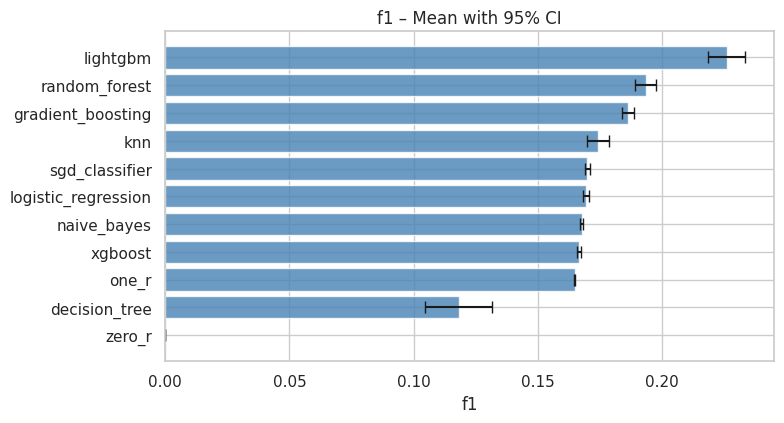

Figure saved to /scratch/indrisch/CP8305FP/reports/figures/03_model_comparison.png


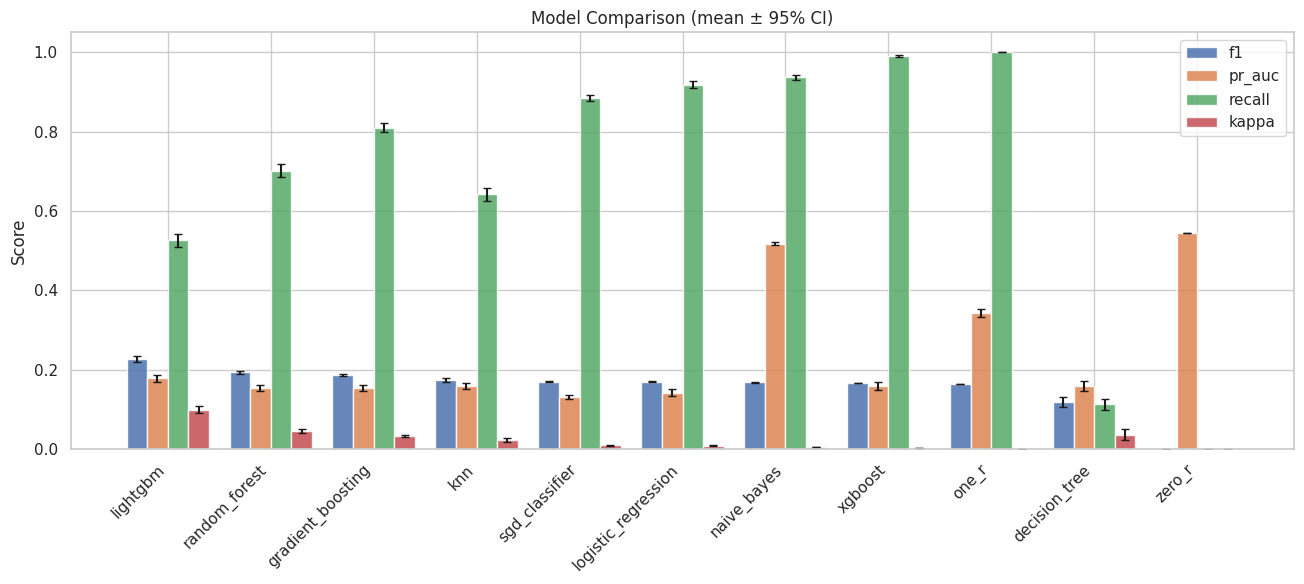

In [9]:
# Build the metrics summary table with 95% CIs from fold distributions.
summary_table = build_metrics_summary_table(experiment_results)
print('=== Model Comparison (sorted by F1, with 95% CIs) ===')
display(summary_table)
summary_table.to_csv(TABLES_DIR / '03_model_comparison.csv')

# Identify best model.
BEST_CLF = summary_table.index[0]
print(f'\nBest model by CV F1: {BEST_CLF}')

# Forest plot of F1 confidence intervals.
fig = plot_confidence_intervals(summary_table, metric='f1')
save_figure(fig, '03_f1_confidence_intervals.png')
plt.show()

# Grouped bar chart across key metrics.
fig = plot_model_comparison(summary_table, metrics=['f1', 'pr_auc', 'recall', 'kappa'])
save_figure(fig, '03_model_comparison.png')
plt.show()

---
## 4.5 SGDClassifier on reduced features (fold-local)

Training **SGDClassifier** on the full ~2.5k one-hot columns is possible but slow; here we compare three **fold-local** reductions first (fit on the training fold only, transform the validation fold—same leakage posture as scaling), then fit SGD on the reduced matrix.

**RFECV** at full dimension would require enormous numbers of model refits per fold. **SelectFromModel** with an ensemble is the practical substitute at this scale; if you need RFECV for a write-up, restrict it to a low-dimensional input (for example after PCA to 50 components) and use a large `step` to limit refits.

The next cell uses **lightweight defaults** for faster runs: **`K_FOLDS`-fold** CV (same as Section 4), **PCA** with 32 components, **SelectKBest** with `k=20`, and **SelectFromModel** capped with `max_features=20`, plus a smaller ensemble for the selector. Increase PCA / k / `max_features` if you need richer features.

In [10]:
from sklearn.base import clone

# Tree/boosting model for SelectFromModel: best mean F1 among advanced models in this CV run.
_advanced_in_run = [
    k for k in CLASSIFICATION_MODELS
    if k in experiment_results and k in CLASSIFICATION_MODELS
]
if _advanced_in_run:
    ref_tree_name = max(
        _advanced_in_run,
        key=lambda k: experiment_results[k]["aggregate"]["f1"]["mean"],
    )
else:
    ref_tree_name = next(
        k for k in ("lightgbm", "xgboost", "random_forest") if k in CLASSIFICATION_MODELS
    )

selector_base = clone(CLASSIFICATION_MODELS[ref_tree_name])
if hasattr(selector_base, "set_params"):
    if ref_tree_name == "lightgbm":
        selector_base.set_params(n_estimators=20, num_leaves=31, max_depth=5, verbose=-1)
    elif ref_tree_name == "xgboost":
        selector_base.set_params(n_estimators=20, max_depth=4, verbosity=0)
    elif ref_tree_name == "catboost":
        selector_base.set_params(iterations=20, depth=5, verbose=0)
    elif ref_tree_name in ("random_forest", "gradient_boosting"):
        selector_base.set_params(n_estimators=25)

print(
    f"SelectFromModel base estimator: {ref_tree_name} "
    "(lighter settings than full CV models for speed)"
)

SGD_REDUCED_MODELS = {"sgd_classifier": CLASSIFICATION_MODELS["sgd_classifier"]}


def _prefix_experiment_results(results: dict, prefix: str) -> dict:
    return {f"{prefix}__{name}": out for name, out in results.items()}


def _run_sgd_reduction(reduction, prefix):
    result = run_cv_experiment(
        X_train,
        y_train,
        model_configs=SGD_REDUCED_MODELS,
        n_splits=K_FOLDS,
        groups=groups_train,
        scale=True,
        imbalance_strategy="class_weight",
        random_state=42,
        reduction=reduction,
        total_cpus=max(1, N_CPUS // 3),
    )
    return _prefix_experiment_results(result, prefix)

_sgd_configs = [
    (("pca", {"n_components": 32}), "pca32"),
    (("select_kbest", {"k": 20}), "kbest20"),
    (
        (
            "select_from_model",
            {
                "estimator": selector_base,
                "threshold": "median",
                "max_features": 20,
            },
        ),
        "sfm_median",
    ),
]

import joblib as _jl
_sgd_parallel = _jl.Parallel(n_jobs=3, backend="loky")(
    _jl.delayed(_run_sgd_reduction)(red, prefix)
    for red, prefix in _sgd_configs
)
sgd_reduced_results = {}
for r in _sgd_parallel:
    sgd_reduced_results.update(r)

sgd_reduced_summary = build_metrics_summary_table(sgd_reduced_results)
print(f"=== SGDClassifier with fold-local dimensionality reduction ({K_FOLDS}-fold CV, light feature settings) ===")
display(sgd_reduced_summary)
sgd_reduced_summary.to_csv(TABLES_DIR / '03_sgd_reduced_comparison.csv')

SelectFromModel base estimator: lightgbm (lighter settings than full CV models for speed)

  Model: sgd_classifier
  Fold  1: F1=0.1789  AUC=0.5680  Kappa=0.0370
  Fold  2: F1=0.1950  AUC=0.5955  Kappa=0.0618
  Fold  3: F1=0.1859  AUC=0.5795  Kappa=0.0434
  Fold  4: F1=0.1863  AUC=0.5857  Kappa=0.0438
  Fold  5: F1=0.1906  AUC=0.5960  Kappa=0.0547
  Fold  6: F1=0.1942  AUC=0.6007  Kappa=0.0519
  Fold  7: F1=0.1850  AUC=0.5757  Kappa=0.0454
  Fold  8: F1=0.1814  AUC=0.5755  Kappa=0.0380
  Fold  9: F1=0.1796  AUC=0.5718  Kappa=0.0398
  Fold 10: F1=0.1851  AUC=0.5886  Kappa=0.0418
            f1: 0.1862 [0.1822, 0.1902]
       auc_roc: 0.5837 [0.5756, 0.5918]
         kappa: 0.0458 [0.0401, 0.0515]

  Model: sgd_classifier


/home/indrisch/.local/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  52   54   55   60   61   78   79   87  154  164  201  217  221  229
  249  264  287  311  312  314  321  324  328  396  419  421  436  455
  483  484  487  509  529  540  555  570  571  574  600  642  662  666
  678  680  712  718  724  742  754  758  759  769  774  782  794  796
  798  801  803  804  807  811  815  826  827  842  886  889  890  927
  979  990  996  999 1000 1012 1014 1088 1099 1101 1118 1120 1134 1142
 1181 1228 1235 1238 1251 1252 1255 1259 1287 1300 1302 1303 1333 1337
 1345 1360 1386 1390 1398 1399 1404 1416 1419 1425 1427 1434 1435 1440
 1443 1450 1455 1456 1471 1477 1480 1483 1484 1497 1499 1502 1510 1514
 1516 1543 1549 1553 1556 1563 1584 1585 1590 1610 1617 1620 1623 1642
 1645 1646 1710 1725 1751 1764 1834 1844 1855 1858 1861 1863 1906 1909
 1972 1980 2000 2002 2003 2022 2051 2060 2065 2094 2107 2121 2128 2137
 2143 2144 2147 215

  Fold  1: F1=0.2155  AUC=0.6283  Kappa=0.0906
  Fold  2: F1=0.2127  AUC=0.6066  Kappa=0.0971
  Fold  3: F1=0.2006  AUC=0.6165  Kappa=0.0627
  Fold  4: F1=0.1982  AUC=0.6093  Kappa=0.0608
  Fold  5: F1=0.2208  AUC=0.6356  Kappa=0.0941
  Fold  6: F1=0.2247  AUC=0.6415  Kappa=0.0970
  Fold  7: F1=0.2081  AUC=0.6178  Kappa=0.0796
  Fold  8: F1=0.1973  AUC=0.6191  Kappa=0.0771
  Fold  9: F1=0.2238  AUC=0.6206  Kappa=0.0979
  Fold 10: F1=0.1641  AUC=0.5362  Kappa=0.0162
            f1: 0.2066 [0.1936, 0.2195]
       auc_roc: 0.6132 [0.5923, 0.6340]
         kappa: 0.0773 [0.0590, 0.0956]

  Model: sgd_classifier


/home/indrisch/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/home/indrisch/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/home/indrisch/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/home/indrisch/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/home/indrisch/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warni

  Fold  1: F1=0.2149  AUC=0.6288  Kappa=0.0882
  Fold  2: F1=0.2256  AUC=0.6270  Kappa=0.1073
  Fold  3: F1=0.2060  AUC=0.6161  Kappa=0.0715
  Fold  4: F1=0.1878  AUC=0.5996  Kappa=0.0494
  Fold  5: F1=0.2177  AUC=0.6349  Kappa=0.0846
  Fold  6: F1=0.2281  AUC=0.6350  Kappa=0.1004
  Fold  7: F1=0.2052  AUC=0.6146  Kappa=0.0711
  Fold  8: F1=0.2057  AUC=0.6175  Kappa=0.0783
  Fold  9: F1=0.2010  AUC=0.6020  Kappa=0.0662
  Fold 10: F1=0.2190  AUC=0.6390  Kappa=0.0951
            f1: 0.2111 [0.2023, 0.2199]
       auc_roc: 0.6214 [0.6116, 0.6313]
         kappa: 0.0812 [0.0687, 0.0937]
=== SGDClassifier with fold-local dimensionality reduction (10-fold CV, light feature settings) ===


/home/indrisch/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/home/indrisch/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(


,f1_mean,f1_std,f1_ci_lower,f1_ci_upper,auc_roc_mean,auc_roc_std,auc_roc_ci_lower,auc_roc_ci_upper,auprc_mean,auprc_std,...,kappa_ci_lower,kappa_ci_upper,brier_score_mean,brier_score_std,brier_score_ci_lower,brier_score_ci_upper,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_ci_lower,balanced_accuracy_ci_upper
model,,,,,,,,,,,,,,,,,,,,,
sfm_median__sgd_classifier,0.211082,0.012269,0.202306,0.219859,0.621449,0.013756,0.611609,0.631290,0.151672,0.015042,...,0.068738,0.093713,0.232276,0.011950,0.223727,0.240824,0.589411,0.014305,0.579179,0.599644
kbest20__sgd_classifier,0.206565,0.018086,0.193627,0.219503,0.613152,0.029118,0.592322,0.633982,0.153385,0.011395,...,0.059032,0.095624,0.235025,0.014492,0.224658,0.245392,0.581686,0.024128,0.564426,0.598946
pca32__sgd_classifier,0.186202,0.005616,0.182184,0.190219,0.583706,0.011281,0.575635,0.591776,0.120217,0.008981,...,0.040052,0.051465,0.248738,0.015320,0.237779,0.259697,0.559300,0.008270,0.553384,0.565216


In [11]:
# Statistical significance: paired t-test and Wilcoxon signed-rank vs. baseline.
significance_df = run_significance_tests(
    experiment_results, baseline_model='zero_r', metric='f1', alpha=0.05,
)
print('=== Statistical Significance Tests (F1 vs. ZeroR baseline) ===')
display(significance_df)
significance_df.to_csv(TABLES_DIR / '03_significance_vs_zeror.csv')

# Also test against logistic regression as a stronger baseline.
significance_lr = run_significance_tests(
    experiment_results, baseline_model='one_r', metric='f1', alpha=0.05,
)
print('\n=== Statistical Significance Tests (F1 vs. Logistic Regression) ===')
display(significance_lr)
significance_lr.to_csv(TABLES_DIR / '03_significance_vs_oner.csv')

=== Statistical Significance Tests (F1 vs. ZeroR baseline) ===


,model,baseline,metric,mean_diff,t_stat,p_value_t,p_value_wilcoxon,significant_t,significant_w
9,lightgbm,zero_r,f1,0.225921,68.724773,1.477300e-13,0.001953,True,True
6,random_forest,zero_r,f1,0.193402,104.163580,3.515237e-15,0.001953,True,True
7,gradient_boosting,zero_r,f1,0.186403,174.870540,3.325816e-17,0.001953,True,True
4,knn,zero_r,f1,0.174300,87.806911,1.633202e-14,0.001953,True,True
5,sgd_classifier,zero_r,f1,0.169890,403.463859,1.796929e-20,0.001953,True,True
2,logistic_regression,zero_r,f1,0.169422,354.579165,5.745459e-20,0.001953,True,True
1,naive_bayes,zero_r,f1,0.167552,496.777575,2.762792e-21,0.001953,True,True
8,xgboost,zero_r,f1,0.166630,536.625648,1.379661e-21,0.001953,True,True
0,one_r,zero_r,f1,0.164798,4186.947511,1.287634e-29,0.001953,True,True
3,decision_tree,zero_r,f1,0.118104,19.673941,1.049552e-08,0.001953,True,True



=== Statistical Significance Tests (F1 vs. Logistic Regression) ===


,model,baseline,metric,mean_diff,t_stat,p_value_t,p_value_wilcoxon,significant_t,significant_w
9,lightgbm,one_r,f1,0.061122,18.652591,1.678170e-08,0.001953,True,True
6,random_forest,one_r,f1,0.028604,15.453822,8.705780e-08,0.001953,True,True
7,gradient_boosting,one_r,f1,0.021605,20.417358,7.566937e-09,0.001953,True,True
4,knn,one_r,f1,0.009502,4.781024,9.998444e-04,0.001953,True,True
5,sgd_classifier,one_r,f1,0.005092,12.452820,5.612940e-07,0.001953,True,True
2,logistic_regression,one_r,f1,0.004624,9.472770,5.605952e-06,0.001953,True,True
1,naive_bayes,one_r,f1,0.002754,8.272357,1.692354e-05,0.001953,True,True
8,xgboost,one_r,f1,0.001832,6.090545,1.813138e-04,0.001953,True,True
3,decision_tree,one_r,f1,-0.046694,-7.769650,2.793286e-05,0.001953,True,True
0,zero_r,one_r,f1,-0.164798,-4186.947511,1.287634e-29,0.001953,True,True


In [12]:
# Compare class-imbalance strategies on train data only (fold-local pipelines).
print(f'Imbalance comparison for best model: {BEST_CLF}')
imbalance_results = compare_imbalance_strategies(
    X_train, y_train,
    model_name=BEST_CLF,
    cv=5,
    groups=groups_train,
    scoring='f1',
    total_cpus=N_CPUS,
)
imbalance_df = pd.DataFrame(imbalance_results).T.sort_values('mean', ascending=False)
print('Imbalance strategy comparison (CV F1):')
display(imbalance_df)
imbalance_df.to_csv(TABLES_DIR / '03_imbalance_comparison.csv')

Imbalance comparison for best model: lightgbm
Imbalance strategy comparison completed.
Imbalance strategy comparison (CV F1):


,mean,std
class_weight_balanced,0.224820,0.005903
baseline,0.015667,0.007247
smote,0.009452,0.004005


In [13]:
# hi

In [ ]:
# Nested CV: inner 5-fold loop tunes hyperparameters, outer K_FOLDS loop evaluates.
# Only models with defined search spaces in HYPERPARAM_GRIDS are tuned.
top_models = {
    k: CLASSIFICATION_MODELS[k]
    for k in list(summary_table.index[:5])
    if k in HYPERPARAM_GRIDS
}
print(f'Tuning top models: {list(top_models.keys())}')

if top_models:
    # Inner GridSearchCV used n_jobs=-1 before: all CPU cores × joblib workers each
    # hold a copy of the outer-fold training data → heavy RAM and fan noise.
    tuned_results = run_tuned_cv_experiment(
        X_train, y_train,
        model_configs=top_models,
        param_grids=HYPERPARAM_GRIDS,
        n_outer_splits=K_FOLDS,
        n_inner_splits=5,
        groups=groups_train,
        scale=True,
        scoring='f1',
        random_state=42,
        total_cpus=N_CPUS,
    )
    tuned_summary = build_metrics_summary_table(tuned_results)
    print('\n=== Tuned Model Comparison (Nested CV, unbiased) ===')
    display(tuned_summary)
    tuned_summary.to_csv(TABLES_DIR / '03_tuned_model_comparison.csv')
else:
    print('No models have defined hyperparameter grids for tuning.')
    tuned_results = {}

In [ ]:
# Train the final best model on the full training set for holdout evaluation.
best_clf_pipeline = train_classifier(X_train, y_train, model_name=BEST_CLF, scale=True)
y_pred_test = best_clf_pipeline.predict(X_test)
y_prob_test = predict_positive_probability(best_clf_pipeline, X_test)

# Holdout set metrics (comprehensive suite).
test_metrics = compute_classification_metrics(y_test.values, y_pred_test, y_prob_test)
print(f'=== Holdout Test Metrics ({BEST_CLF}) ===')
for k, v in test_metrics.items():
    print(f'  {k:>20s}: {v:.4f}')

# Top-K metrics (operational capacity simulation).
topk = compute_topk_metrics(y_test.values, y_prob_test)
print('\n=== Top-K Metrics (capacity simulation) ===')
for label, vals in topk.items():
    print(f'  {label}: Precision@K={vals["precision_at_k"]:.4f}, Recall@K={vals["recall_at_k"]:.4f} (k={vals["k"]})')

In [ ]:
# ROC and Precision-Recall curves from out-of-fold probabilities.
fig = plot_roc_curves(experiment_results, y_train)
save_figure(fig, '03_roc_curves.png')
plt.show()

fig = plot_pr_curves(experiment_results, y_train)
save_figure(fig, '03_pr_curves.png')
plt.show()

# Confusion matrices: default threshold vs. recall-tuned threshold.
fig = plot_confusion_matrix(y_test, y_pred_test, title=f'{BEST_CLF} (threshold=0.50)')
save_figure(fig, '03_confusion_matrix.png')
plt.show()

threshold_results = tune_decision_threshold(y_test, y_prob_test, metric='recall')
best_threshold = threshold_results['best_threshold']
y_pred_tuned = (y_prob_test >= best_threshold).astype(int)

fig = plot_confusion_matrix(
    y_test, y_pred_tuned,
    title=f'{BEST_CLF} (threshold={best_threshold:.2f})',
)
save_figure(fig, '03_confusion_matrix_threshold_tuned.png')
plt.show()

---
## 5. Cost-Sensitive Business Evaluation
Evaluate models against an FN-heavy cost matrix aligned to Hospital Readmissions Reduction Program (HRRP) penalties. False negatives (missed readmissions) are far more costly than false positives (unnecessary interventions).

In [ ]:
# Cost matrix aligned to HRRP readmission penalties.
print('Cost matrix (per prediction outcome):')
for k, v in DEFAULT_COST_MATRIX.items():
    print(f'  {k}: ${v:,.0f}')

# Threshold sweep: expected cost and recall at each threshold.
cost_sweep = sweep_thresholds_cost(y_test.values, y_prob_test)

fig = plot_cost_threshold_sweep(cost_sweep)
save_figure(fig, '03_cost_threshold_sweep.png')
plt.show()

# Compare default vs. cost-optimal operating point.
best_cost_row = cost_sweep.sort_values('total_cost').iloc[0]
default_cost = compute_expected_cost(y_test.values, y_pred_test)

print(f'Cost-optimal threshold: {best_cost_row["threshold"]:.2f}')
print(f'  Total cost:  ${best_cost_row["total_cost"]:,.0f}')
print(f'  Recall:      {best_cost_row["recall"]:.4f}')
print(f'\nDefault threshold (0.50):')
print(f'  Total cost:  ${default_cost["total_cost"]:,.0f}')
print(f'  FN={default_cost["fn"]}, FP={default_cost["fp"]}')

In [ ]:
# Calibration diagnostics: do predicted probabilities match observed frequencies?
fig = plot_calibration_curves(experiment_results, y_train, n_bins=10)
save_figure(fig, '03_calibration_curves.png')
plt.show()

# Brier score for the best model on the holdout set.
cal_diag = compute_calibration_diagnostics(y_test.values, y_prob_test)
print(f'Brier score ({BEST_CLF}): {cal_diag["brier_score"]:.4f}')
print('(Lower is better; 0 = perfect calibration)')

---
## 6. Explainability (XAI) & Knowledge Discovery
SHAP global/local explanations, permutation importance, partial dependence plots, and human-readable rule export for clinical deployment.

In [ ]:
# SHAP global feature importance for the best model.
if SHAP_AVAILABLE:
    shap_values, shap_explainer, X_shap_sample = compute_shap_values(
        best_clf_pipeline, X_test, feature_names=list(X_train.columns),
    )
    fig = plot_shap_summary(shap_values, X_shap_sample, max_display=20)
    save_figure(fig, '03_shap_summary.png')
    plt.show()
else:
    print('SHAP not installed. Install via: pip install shap')

In [ ]:
# Permutation importance on holdout set (model-agnostic).
fig = plot_permutation_importance(best_clf_pipeline, X_test, y_test, top_n=20)
save_figure(fig, '03_permutation_importance.png')
plt.show()

# Partial Dependence Plots for top features (tree-based models only).
try:
    inner_model = best_clf_pipeline.named_steps.get('classifier')
    if hasattr(inner_model, 'feature_importances_'):
        top_idx = np.argsort(inner_model.feature_importances_)[::-1][:6]
        top_feature_names = [X_train.columns[i] for i in top_idx]
        fig = plot_pdp(best_clf_pipeline, X_test, top_feature_names)
        save_figure(fig, '03_partial_dependence.png')
        plt.show()
    else:
        print(f'PDP: {BEST_CLF} does not expose feature_importances_; skipping PDP.')
except Exception as e:
    print(f'PDP not available for this model type: {e}')

In [ ]:
# Extract human-readable decision rules for clinical deployment.
# Decision tree rules (full model).
dt_pipeline = train_classifier(X_train, y_train, model_name='decision_tree', scale=False)
dt_model = dt_pipeline.named_steps['classifier']
dt_rules = export_tree_rules(dt_model, feature_names=list(X_train.columns), max_depth=5)
print('=== Decision Tree Rules (max depth 5) ===')
print(dt_rules)

# Random forest top-tree rules (representative subset of the ensemble).
rf_pipeline = train_classifier(X_train, y_train, model_name='random_forest', scale=False)
rf_model = rf_pipeline.named_steps['classifier']
rf_rules = export_forest_top_rules(
    rf_model, feature_names=list(X_train.columns), n_trees=3, max_depth=3,
)
print('\n=== Random Forest – Top 3 Tree Rules (max depth 3) ===')
for rule in rf_rules:
    print(rule)

---
## Optional: Regression Models
_These sections are preserved for reference but are not part of the readmission classification analysis._

In [ ]:
reg_results = {}
for name in REGRESSION_MODELS:
    print(f'\n--- {name} ---')
    pipeline = train_regressor(X_train, y_train, model_name=name, scale=True)
    metrics = evaluate_regressor(pipeline, X_test, y_test)
    reg_results[name] = metrics

print('\n=== RMSE Summary ===')
for name, m in sorted(reg_results.items(), key=lambda x: x[1]['rmse']):
    print(f'{name:<25} RMSE={m["rmse"]:.4f}  R²={m["r2"]:.4f}')

In [ ]:
BEST_REG = min(reg_results, key=lambda k: reg_results[k]['rmse'])
best_reg_pipeline = train_regressor(X_train, y_train, model_name=BEST_REG, scale=True)
y_pred_reg = best_reg_pipeline.predict(X_test)

fig = plot_residuals(y_test, y_pred_reg, title=f'Residual Plot – {BEST_REG}')
save_figure(fig, '03_residuals.png')
plt.show()

---
## Optional: Clustering
_These sections are preserved for reference but are not part of the readmission classification analysis._

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale features before clustering
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Elbow method
elbow_data = find_optimal_k(X_scaled, k_range=range(2, 11))
fig = plot_elbow_curve(elbow_data)
save_figure(fig, '03_elbow_curve.png')
plt.show()

In [ ]:
# TODO: Set k based on the elbow plot above.
OPTIMAL_K = 3

kmeans_model, cluster_labels = train_kmeans(X_scaled, n_clusters=OPTIMAL_K)

# TODO: Replace 'feature_x' and 'feature_y' with two informative feature names.
# fig = plot_cluster_scatter(X_scaled, cluster_labels, 'feature_x', 'feature_y')
# save_figure(fig, '03_cluster_scatter.png')
# plt.show()

## 5. Feature Importance

In [ ]:
# Works for tree-based classifiers/regressors. Adapt model variable as needed.
# Assumes the last step in the pipeline is named 'classifier' or 'regressor'.
try:
    inner_model = best_clf_pipeline.named_steps.get('classifier') \
                  or best_clf_pipeline.named_steps.get('regressor')
    if hasattr(inner_model, 'feature_importances_'):
        fig = plot_feature_importance(inner_model, list(X.columns), top_n=20)
        save_figure(fig, '03_feature_importance.png')
        plt.show()
except Exception as e:
    print(f'Feature importance not available: {e}')

## 6. Save Best Model

In [ ]:
save_model(best_clf_pipeline, 'best_classifier.pkl')
print('Modeling complete. Proceed to Notebook 4 – Analysis & Findings.')